# RODM方法在OFPV系统的应用及优势
## 本程序用于后处理，处理work4的结果文件。

In [1]:
#import packages
import time
import numpy as np
import scipy
import matplotlib.pyplot as plt
from DM_Verify import process_exp_data
import pandas as pd
from scipy.interpolate import interp1d

In [2]:
wavelength = 300
direction = 270
Serep_wl60_d0 = np.load(f"E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\Serep_wl{wavelength}_d{direction}.npy")
Static_wl60_d0 = np.load(f"E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\Static_wl{wavelength}_d{direction}.npy")
dynamic_wl60_d0 = np.load(f"E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\dynamic_wl{wavelength}_d{direction}.npy")
# 读取三维水弹性结果yago

yago = pd.read_csv(f'E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\Yago-{wavelength}-{direction-180}.csv', header=None)
# yago = pd.read_csv(f'E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\chen-180-180-2.csv', header=None)

In [ ]:
# 使用 pandas 读取 Yago 数据
# 提取 Yago 数据中的 x 和 y
yago_x = yago.iloc[:, 0].values  # 第一列是 x 坐标
yago_data = yago.iloc[:, 1].values  # 第二列是 y 数据，并反转顺序

# 提取 x_present 作为插值目标的 x 坐标
x_present = np.linspace(0, 1, 61)

# 创建插值函数，将 Yago 数据插值到与其他模型数据相同的 x 坐标
interp_func = interp1d(yago_x, yago_data, kind='linear', fill_value="extrapolate")
yago_interpolated = interp_func(x_present)

# 提取其他模型的对应数据
Static_A = abs(Static_wl60_d0[366:427, 2][::-1])  # Static-A 数据
Static_B = abs(dynamic_wl60_d0[366:427, 2][::-1])  # Static-B 数据
Serep = abs(Serep_wl60_d0[366:427, 2])  # Serep 数据

# 计算相对误差
def relative_error(model_data, yago_data):
    return np.abs((model_data - yago_data) / yago_data) * 100

# 计算每个模型的相对误差
error_Static_A = relative_error(Static_A, yago_interpolated)
error_Static_B = relative_error(Static_B, yago_interpolated)
error_Serep = relative_error(Serep, yago_interpolated)

# 输出各模型的平均相对误差
print(f"Average Relative Error for Static-A: {np.mean(error_Static_A)}%")
print(f"Average Relative Error for Static-B: {np.mean(error_Static_B)}%")
print(f"Average Relative Error for Serep: {np.mean(error_Serep)}%")

# 绘制对比图
plt.plot(x_present, yago_interpolated, label='Yago and Endo')
plt.plot(x_present, Static_A, label="Static-A")
plt.plot(x_present, Static_B, label="Static-B")
plt.plot(x_present, Serep, label="Serep")

plt.legend()
plt.ylim(0, 2)  # 调整y轴坐标
plt.xlabel('x/L')
plt.ylabel('Heave RAO (m/m)')
plt.savefig(f"validation_{wavelength}_{direction}.pdf", bbox_inches='tight', dpi = 300)
plt.show()

In [ ]:

# 读取实验数据
def process_exp_data(file_path):
    data = np.loadtxt(file_path)
    return data[:, 0], data[:, 1]

# 读取实验数据
x_exp, y_exp = process_exp_data(f"E:\\phd\\Code\\DM-FEM2D\\data\\Experiment_300_60\\exp_{wavelength}.txt")
y_exp = np.array(y_exp)

# 读取 Fu et al. 的数据
x_sim_fu, y_sim_fu = process_exp_data(f"E:\\phd\\Code\\DM-FEM2D\\data\\Experiment_300_60\\fu_sim{wavelength}.txt")
y_sim_fu = np.array(y_sim_fu)

# 确保 x_sim_fu 是递增的
if np.any(np.diff(x_sim_fu) < 0):
    print("Warning: x_sim_fu is not sorted. Sorting...")
    sorted_indices = np.argsort(x_sim_fu)
    x_sim_fu = x_sim_fu[sorted_indices]
    y_sim_fu = y_sim_fu[sorted_indices]

# 定义插值坐标
x_present = np.linspace(0, 1, 61)

# 创建插值函数，将 Fu et al. 数据插值到与其他模型数据相同的 x 坐标
interp_func_fu = interp1d(x_sim_fu, y_sim_fu, kind='cubic', fill_value="extrapolate")
y_sim_fu_interpolated = interp_func_fu(x_present)

# 提取其他模型的对应数据
Static_A = abs(Static_wl60_d0[366:427, 2][::-1])  # Static-A 数据
Static_B = abs(dynamic_wl60_d0[366:427, 2][::-1])  # Static-B 数据
Serep = abs(Serep_wl60_d0[366:427, 2])  # Serep 数据

# 对实验数据进行插值，将其插值到与 x_present 相同的坐标
# interp_func_exp = interp1d(x_exp, y_exp, kind='cubic', fill_value="extrapolate")
# y_exp_interpolated = interp_func_exp(x_present)

# 计算相对误差
def relative_error(model_data, exp_data):
    return np.abs((model_data - exp_data) / exp_data) * 100

# 计算每个模型的相对误差
error_Static_A = relative_error(Static_A, y_sim_fu_interpolated)
error_Static_B = relative_error(Static_B, y_sim_fu_interpolated)
error_Serep = relative_error(Serep, y_sim_fu_interpolated)

# 输出各模型的平均相对误差
print(f"Average Relative Error for Static-A: {np.mean(error_Static_A)}%")
print(f"Average Relative Error for Static-B: {np.mean(error_Static_B)}%")
print(f"Average Relative Error for Serep: {np.mean(error_Serep)}%")

# 绘制 Fu et al. 数据的插值结果
plt.plot(x_present, y_sim_fu_interpolated, label="Fu et al.")

# 绘制其他模型的结果
plt.plot(x_present, Static_A, label="Static-A")
plt.plot(x_present, Static_B, label="Static-B")
plt.plot(x_present, Serep, label="Serep")

# 绘制实验数据
plt.scatter(x_exp, y_exp, label="Experiment", s=10)

# 设置标签和标题
plt.legend()
plt.ylim(0, 2)  # 调整y轴坐标
plt.xlabel('x/L')
plt.ylabel('Heave RAO (m/m)')
#plt.title(f"Comparison of Heave RAO with Relative Errors")
#plt.grid(True)
# plt.show()
plt.savefig(f"validation_{wavelength}_{direction}.pdf", bbox_inches='tight', dpi = 300)


### 验证部分：对比内力计算的数据

In [ ]:
wavelength = 145
direction = 180     
Serep_wl60_d0 = np.load(f"E:\phd\Code\DM-FEM2D\FEM_Reduce\Serep_wl145_d180.npy")
Static_wl60_d0 = np.load(f"E:\phd\Code\DM-FEM2D\FEM_Reduce\Static_wl145_d180.npy")

In [ ]:
plt.plot(abs(Serep_wl60_d0[366:427,2]))
plt.plot(abs(Static_wl60_d0[366:427,2])[::-1])
plt.legend(['Serep', 'Static'])

In [ ]:
plt.plot(np.angle(Serep_wl60_d0[366:427,2]))
plt.plot(np.angle(Static_wl60_d0[366:427,2])[::-1])
plt.legend(['Serep', 'Static'])

In [ ]:
plt.imshow(np.abs(Static_wl60_d0[:,2].reshape(13,61)))

In [ ]:
plt.imshow(np.angle(Static_wl60_d0[:,2].reshape(13,61)))

In [ ]:
plt.imshow(np.angle(Serep_wl60_d0[:,2].reshape(13,61)))

In [3]:
import pandas as pd  
import matplotlib.pyplot as plt  
import numpy as np 
import scienceplots  

# 使用科学风格的绘图主题（IEEE 规范）  
plt.style.use(['science', 'no-latex', 'ieee'])  

# 读取 Excel 文件  
fu_data = pd.read_excel(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\valiation_force\FU.xlsx')  
force_data = pd.read_excel(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\valiation_force\force_compare.xlsx')  

# 初步查看数据  
print(fu_data.head())  
print(force_data.head())  

# 提取感兴趣的列并归一化（将数据范围变为 0-1）  
def normalize(column):  
    return (column - column.min()) / (column.max() - column.min())  

# 假定 FU 数据的横坐标为第一个列，纵坐标是目标列  
fu_x = normalize(fu_data.iloc[:, 0])  # 横坐标  
fu_y = normalize(fu_data.iloc[:, 1])  # Fu的值  

# 假定 force_compare 的每列皆为需要对比的数据列  
force_x = normalize(force_data.iloc[:, 0])  # 横坐标  
force_y_all = force_data.iloc[:, 1:]       # Force_compare中所有其他列
serep_stress = np.array(force_y_all["stress"]).reshape(13,61)
# serep_stress = np.sum(serep_stress, axis=0)
# max_value = np.max(serep_stress)
# serep_stress = serep_stress / max_value
# force_y_normalized = force_y_all.apply(normalize)  # 对每列数据进行归一化  

# # # 反转 R 数据 (假设 R 是 “force_compare” 的最后一列)  
# # if 'R' in force_data.columns:  
# #     force_y_normalized['R'] = 1 - force_y_normalized['R']  

# static_stress_all = np.array(force_y_normalized["all dof"])
# static_stress_3 = np.array(force_y_normalized["only 3"])
# force_x  = np.linspace(0, 1, 61)
# # 绘制 FU 数据  
# plt.plot(fu_x, fu_y, label='Fu et al.')  
# plt.plot(force_x, serep_stress[::-1], label='SEREP')
# plt.plot(force_x, static_stress_all[0:61], label='Static')
# # plt.plot(force_x, static_stress_3, label='Static 3', linestyle='-', color='black')

# # 添加坐标轴标题  
# plt.xlabel('x/L')  # 横坐标命名为 x/L  
# plt.ylabel('Normalized normal stress')  # 纵坐标命名为归一化的结果  

# plt.legend()  
# plt.ylim(0, 1.2)  # 调整y轴坐标
# plt.savefig("force_date.pdf", dpi=300)
# # 显示图像  
# plt.show()

   Normalized X        Fu
0      0.000000  0.474529
1      0.002004  1.181006
2      0.004008  1.844834
3      0.006012  2.485539
4      0.008016  3.122644
   ndoe    all dof     only 3         R       New    stress
0   1.0    67888.2   289622.0   13826.2   13470.3   29844.2
1   2.0    14553.7   176148.0   31366.7   34893.1   51328.6
2   3.0   950627.0   845328.0   69635.2   90074.4  104967.0
3   4.0   328968.0   376060.0  109055.0  158815.0  171711.0
4   5.0  1573080.0  1656790.0  146720.0  225417.0  237981.0


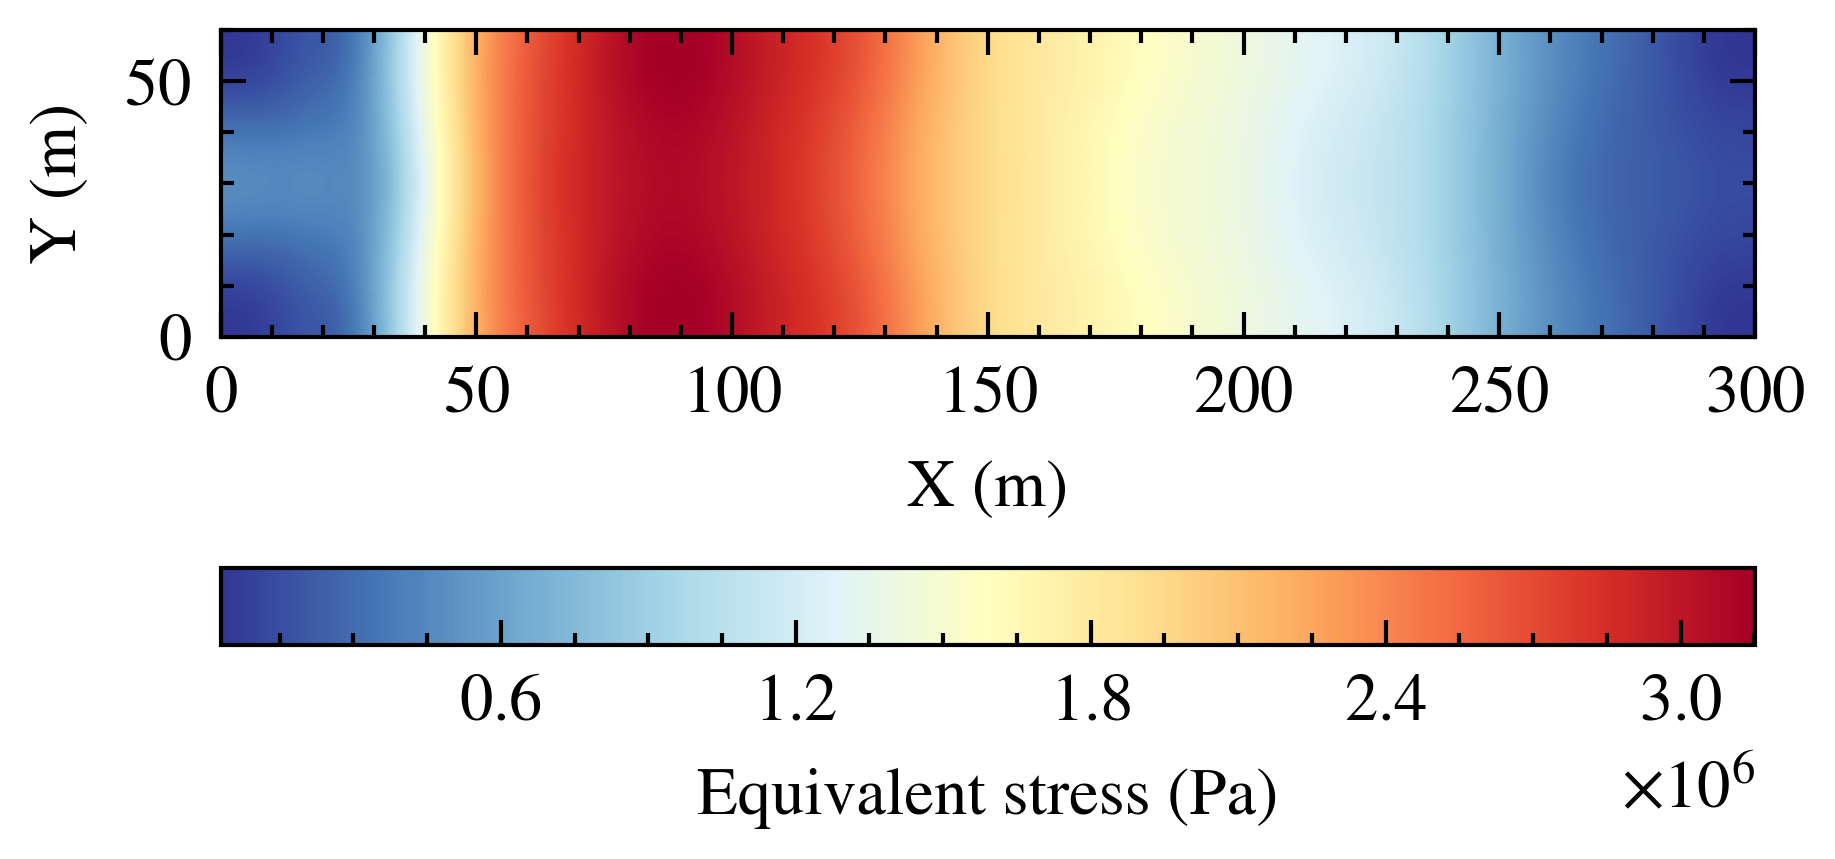

In [12]:
im = plt.imshow(np.rot90(serep_stress, k=2),interpolation='spline16',extent=(0, 300, 0, 60),cmap='RdYlBu_r')
from matplotlib.ticker import MaxNLocator, ScalarFormatter
cbar = plt.colorbar(im, orientation='horizontal', pad=0.2)
cbar.set_label("Equivalent stress (Pa)")
cbar.locator = MaxNLocator(nbins=6)
cbar.update_ticks()
# plt.colorbar(label="Displacement (Root Mean Square)")
# plt.title("Wind Displacement Root Mean Square")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.savefig("allstress_1.pdf", format='pdf', dpi=300, bbox_inches='tight')

### 验证部分：相对误差分析

In [ ]:
import matplotlib.pyplot as plt  
import seaborn as sns  
import numpy as np  

# Set the font scale for all seaborn plots  
sns.set(font_scale=1.5)  # 增加整体字体大小  

# Heatmap data for all three models  
heatmap_data_a = np.array([  
    [8.60, 7.98, 23.22, 2.99],  # Static-A: 60m  
    [8.90, 8.34, 3.83, 4.07],   # Static-A: 120m  
    [8.42, 7.13, 3.72, 4.89],   # Static-A: 180m  
    [6.09, 9.37, 3.75, 3.81]    # Static-A: 300m  
])  

heatmap_data_b = np.array([  
    [6.63, 8.50, 27.56, 5.14],  # Static-B: 60m  
    [21.56, 12.63, 7.73, 3.87], # Static-B: 120m  
    [12.74, 9.00, 7.05, 3.66],  # Static-B: 180m  
    [6.44, 11.75, 6.35, 2.89]   # Static-B: 300m  
])  

heatmap_data_serep = np.array([  
    [14.36, 16.92, 15.52, 2.58], # Serep: 60m  
    [12.68, 16.40, 6.81, 3.87],  # Serep: 120m  
    [13.91, 6.98, 3.63, 4.79],   # Serep: 180m  
    [4.24, 2.88, 1.88, 3.76]     # Serep: 300m  
])  

# Mean errors for each model  
mean_error_a = np.mean(heatmap_data_a)  
mean_error_b = np.mean(heatmap_data_b)  
mean_error_serep = np.mean(heatmap_data_serep)  

# Plotting heatmaps for each model with shared colorbar  
plt.figure(figsize=(18, 6))  
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)  

# 设置全局字体大小  
plt.rcParams.update({'font.size': 14})  # 设置基础字体大小  

# Static-A heatmap  
sns.heatmap(heatmap_data_a, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=25,  
            xticklabels=['180°', '210°', '240°', '270°'],   
            yticklabels=['60m', '120m', '180m', '300m'],   
            ax=axes[0],   
            cbar=False,  
            annot_kws={'size': 12})  # 设置数值标注的字体大小  

axes[0].set_title(f"Static-A\nMean Error: {mean_error_a:.2f}%", fontsize=16, pad=10)  # 设置标题字体大小  
axes[0].set_xlabel("Wave Direction", fontsize=14)  # 设置x轴标签字体大小  
axes[0].set_ylabel("Wavelength", fontsize=14)  # 设置y轴标签字体大小  
# 设置刻度标签的字体大小  
axes[0].tick_params(axis='both', which='major', labelsize=12)  

# Static-B heatmap  
sns.heatmap(heatmap_data_b, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=25,  
            xticklabels=['180°', '210°', '240°', '270°'],   
            yticklabels=['60m', '120m', '180m', '300m'],   
            ax=axes[1],   
            cbar=False,  
            annot_kws={'size': 12})  

axes[1].set_title(f"Static-B\nMean Error: {mean_error_b:.2f}%", fontsize=16, pad=10)  
axes[1].set_xlabel("Wave Direction", fontsize=14)  
axes[1].tick_params(axis='both', which='major', labelsize=12)  

# Serep heatmap  
sns.heatmap(heatmap_data_serep, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=25,  
            xticklabels=['180°', '210°', '240°', '270°'],   
            yticklabels=['60m', '120m', '180m', '300m'],   
            ax=axes[2],   
            cbar=False,  
            annot_kws={'size': 12})  

axes[2].set_title(f"Serep\nMean Error: {mean_error_serep:.2f}%", fontsize=16, pad=10)  
axes[2].set_xlabel("Wave Direction", fontsize=14)  
axes[2].tick_params(axis='both', which='major', labelsize=12)  

plt.tight_layout()  

# Save the figure as a high-quality PDF file  
plt.savefig("model_heatmaps.pdf", dpi=300, bbox_inches="tight", format="pdf")

### 讨论部分：不均匀波的等效应力对比

In [ ]:
# 导入必要库  
import pandas as pd  
import matplotlib.pyplot as plt  
import numpy as np  
import scienceplots  

# 使用科学风格的绘图主题（IEEE 规范）  
plt.style.use(['science', 'no-latex', 'ieee'])  

# 读取 Excel 文件  
file_path = r'E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\results_uneven_force102\Force102.xlsx'  
uneven_052 = pd.read_excel(file_path)  

# 初步查看数据，建议用列信息检查  
print("列名查看: ", uneven_052.columns)  # 检查列名是否存在问题  
print(uneven_052.head())  # 显示前5行数据  

# 数据提取与单位转换：将帕斯卡 (Pa) 转换为兆帕 (MPa)，即除以 1e6  
response_50 = np.array(uneven_052[50]) / 1e6  
response_70 = np.array(uneven_052[70]) / 1e6  
response_90 = np.array(uneven_052[90]) / 1e6  
response_uneven = np.array(uneven_052["uneven"]) / 1e6  

# 横坐标 x 的数据生成 (归一化处理 x / L)  
L = 1  # 尺寸参考长度，如 L = 1  
force_x = np.linspace(0, L, len(response_50))  # 基于长度，产生均匀分布的横坐标  

# 创建绘图  
plt.plot(force_x, response_uneven, label='Inhomo. wave')  # 不均匀波  
plt.plot(force_x, response_50, label=r'Homo. wave with $\theta$=50$^\circ$')  # 均匀波θ=50°  
plt.plot(force_x, response_70, label=r'Homo. wave with $\theta$=70$^\circ$')  # 均匀波θ=70°  
plt.plot(force_x, response_90, label=r'Homo. wave with $\theta$=90$^\circ$')  # 均匀波θ=90°  


# 设置图例和绘图样式  
plt.legend()  # 设置图例字体大小  
plt.xlabel(r"x/L")  # x轴标签：x/L  
plt.ylabel("Stress (MPa)")  # y轴标签：应力（单位转为 MPa）  
plt.ylim(0,9)
#plt.title("Stress Response under Inhomo. and Homo. Waves", fontsize=14)  # 可选：标题  


plt.tight_layout()  # 调整图形布局  
plt.savefig("stress102.pdf", format='pdf', dpi=300, bbox_inches='tight') 
plt.show()

### 讨论部分：复杂结构的水弹性响应

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import scienceplots  
# 使用科学风格的绘图主题（IEEE 规范）  
plt.style.use(['science', 'no-latex', 'ieee'])  

In [ ]:
displacement_0 = np.load("E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\complex_interconnect\global_displacement_45.npy")
displacement_8 = np.load("E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\complex_interconnect\global_displacement_45_1e8.npy")
displacement_9 = np.load("E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\complex_interconnect\global_displacement_45_1e9.npy")
displacement_10 = np.load("E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\complex_interconnect\global_displacement_45_1e10.npy")
heave_0 = abs(displacement_0[2::5,:])
heave_8 = abs(displacement_8[2::5,:])
heave_9 = abs(displacement_9[2::5,:])
heave_10 = abs(displacement_10[2::5,:])

In [ ]:
def stitch_heave(heave_module, num_modules_per_row=10, num_modules_per_col=10):
    """
    将 heave 模块拼接成一个大矩阵。
    
    :param heave_module: 形状为 (total_modules, module_height, module_width) 的 3D 数据
    :param num_modules_per_row: 每行的模块数量
    :param num_modules_per_col: 每列的模块数量
    :return: 拼接后的大矩阵
    """
    # 检查输入形状是否符合要求
    total_modules, module_height, module_width = heave_module.shape
    if total_modules != num_modules_per_row * num_modules_per_col:
        raise ValueError("模块数量与给定行列数不匹配。")

    # 初始化大矩阵
    stitched_matrix = np.zeros((module_height * num_modules_per_col, module_width * num_modules_per_row))

    # 拼接模块
    for row in range(num_modules_per_col):
        for col in range(num_modules_per_row):
            module_index = row * num_modules_per_row + col
            start_row = row * module_height
            start_col = col * module_width
            stitched_matrix[start_row:start_row + module_height, start_col:start_col + module_width] = heave_module[module_index]
    
    #删除模块之间的重叠行和列
    overlap_row_indices = [(i + 1) * module_height - 1 for i in range(num_modules_per_col - 1)]
    overlap_col_indices = [(i + 1) * module_width - 1 for i in range(num_modules_per_row - 1)]

    stitched_matrix = np.delete(stitched_matrix, overlap_row_indices, axis=0)
    stitched_matrix = np.delete(stitched_matrix, overlap_col_indices, axis=1)

    return stitched_matrix

# 示例使用
# 假设 heave 已经 reshape 为 (100, 7, 7)

# stitched_result 的形状为 (70, 70)

In [ ]:
heave_module_0 = heave_0.reshape(100, 7, 7)
heave_module_8 = heave_8.reshape(100, 7, 7)
heave_module_9 = heave_9.reshape(100, 7, 7)
heave_module_10 = heave_10.reshape(100, 7, 7)

stitched_result_0 = stitch_heave(heave_module_0, num_modules_per_row=10, num_modules_per_col=10)
stitched_result_8 = stitch_heave(heave_module_8, num_modules_per_row=10, num_modules_per_col=10)
stitched_result_9 = stitch_heave(heave_module_9, num_modules_per_row=10, num_modules_per_col=10)
stitched_result_10 = stitch_heave(heave_module_10, num_modules_per_row=10, num_modules_per_col=10)


In [ ]:
plt.imshow(stitched_result_0, cmap='viridis', interpolation='spline16') #, interpolation='spline16'
plt.colorbar()

In [ ]:
import pandas as pd  

# 读取CSV文件  
yoon = pd.read_csv("E:\\phd\\Code\\DM-FEM2D\\FEM_Reduce\\RODM_Ad_data\\complex_interconnect\\Yoon_continues_180.csv")  

# 如果需要numpy数组  
yoon_array = yoon.to_numpy()  
x = np.linspace(0, 1, 61)


In [ ]:
plt.plot(yoon_array[:,0], yoon_array[:,1])
plt.plot(x,abs(stitched_result_10[0,:]))
plt.plot(x,abs(stitched_result_10[30,:]))
plt.plot(x,abs(stitched_result_10[59,:]))
plt.ylim(0, 2.5)
plt.legend(['Yoon', '0', '30', '60'])

In [ ]:

plt.plot(x,abs(stitched_result_0[29,:]))
plt.plot(x,abs(stitched_result_8[29,:]))
plt.plot(x,abs(stitched_result_9[29,:]))
plt.plot(x,abs(stitched_result_10[29,:]))
#plt.plot(yoon_array[:,0], yoon_array[:,1])
plt.ylim(0, 2)
plt.legend(['hinge', '1e8', '1e9', '1e10'])
plt.xlabel('x/L')
plt.ylabel('Heave displacement (m)')
plt.savefig("heave_45_middle.pdf", dpi=300, bbox_inches='tight')

In [ ]:
import pandas as pd  

# 读取CSV文件  
yoon1 = pd.read_csv("E:\\phd\\Code\\DM-FEM2D\\FEM_Reduce\\RODM_Ad_data\\complex_interconnect\\Yoon_continues_180.csv")  
yoon2 = pd.read_csv("E:\\phd\\Code\\DM-FEM2D\\FEM_Reduce\\RODM_Ad_data\\complex_interconnect\\Yoon_continues_180_new.csv")
# 如果需要numpy数组  
yoon_array1 = yoon1.to_numpy()
yoon_array2 = yoon2.to_numpy() 
plt.plot(yoon_array1[:,0], yoon_array1[:,1])
plt.plot(yoon_array2[:,0], yoon_array2[:,1])
